# 09 - Business Insight & Recommendation

**Project:** Customer Financial Behavior Analysis for Banking Business Intelligence

Tahap ini menerjemahkan hasil analisis dan clustering menjadi insight bisnis serta rekomendasi strategis yang dapat diimplementasikan.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme()

cluster = pd.read_csv("customer_clustered.csv")
profile = pd.read_csv("cluster_profile_summary.csv")

cluster.head()

,CustomerAge,TransactionAmount,AccountBalance,LoginAttempts,TransactionDuration,TransactionHour,DaysSincePreviousTransaction,TotalTransactionPerAccount,AverageTransaction,AverageBalance,DebitCount,CreditCount,DebitRatio,CreditRatio,FavoriteChannel,FavoriteMerchant,Cluster
0,-1.146873,-1.165862,-1.067993,-0.387886,-0.325044,0.0,-1.790369,-1.123271,-1.165862,-1.067993,-0.847497,-0.981108,1.034871,-1.034872,0.335019,-0.946900,1
1,1.546156,0.414515,-0.319887,0.091887,-0.261130,0.0,0.340547,0.845636,0.414515,-0.319887,1.081289,-0.085078,0.367206,-0.367205,0.335019,0.738472,1
2,1.429068,0.022949,1.041842,-0.387886,-1.905859,0.0,1.473452,0.058073,0.022949,1.041842,0.116896,-0.085078,0.100139,-0.100139,-0.960562,0.100763,1
3,1.136347,0.134582,-1.164659,-0.387886,-0.121680,0.0,-1.056950,1.239417,0.134582,-1.164659,1.563486,-0.085078,0.450664,-0.450664,0.335019,-0.582495,1
4,0.433818,0.939134,-0.330681,-0.387886,0.694788,0.0,-0.015149,1.633198,0.939134,-0.330681,2.045682,-0.085078,0.515576,-0.515576,0.335019,-0.992451,1


In [ ]:
# Jumlah pelanggan per cluster
summary = cluster["Cluster"].value_counts().sort_index().reset_index()
summary.columns=["Cluster","Customers"]

summary

,Cluster,Customers
0,0,195
1,1,300


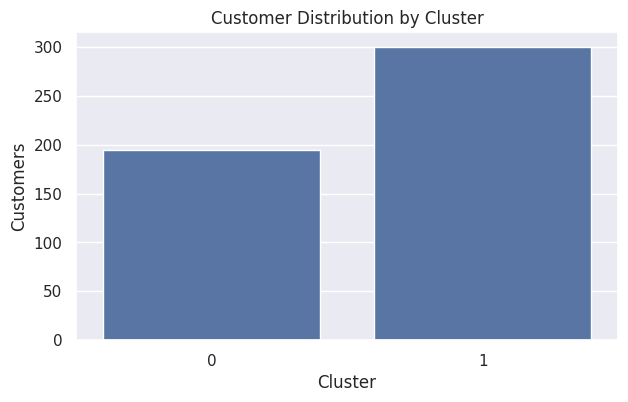

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(data=summary,x="Cluster",y="Customers")
plt.title("Customer Distribution by Cluster")
plt.show()

In [ ]:
# Ringkasan statistik bisnis
business_summary = cluster.groupby("Cluster").agg({
    "TransactionAmount":"mean",
    "AccountBalance":"mean",
    "DebitRatio":"mean",
    "CreditRatio":"mean",
    "TotalTransactionPerAccount":"mean"
}).round(2)

business_summary

,TransactionAmount,AccountBalance,DebitRatio,CreditRatio,TotalTransactionPerAccount
Cluster,,,,,
0,0.04,0.06,-1.00,1.00,0.11
1,-0.03,-0.04,0.65,-0.65,-0.07


## Business Insights

### Cluster 0 – Credit-Oriented High Activity Customers
- Memiliki nilai transaksi, saldo rekening, dan total transaksi yang sedikit lebih tinggi dibandingkan rata-rata pelanggan.
- Memiliki Credit Ratio yang sangat tinggi dan Debit Ratio yang rendah, menunjukkan bahwa pelanggan lebih sering menerima dana dibandingkan melakukan pengeluaran.
- Berpotensi merupakan nasabah dengan arus kas yang stabil, seperti penerima gaji atau pelanggan dengan aktivitas finansial yang sehat.
- Layak ditawarkan produk investasi, deposito, Priority Banking, Wealth Management, dan layanan premium lainnya.

### Cluster 1 – Debit-Oriented Low Activity Customers
- Memiliki nilai transaksi, saldo rekening, dan total transaksi yang sedikit lebih rendah dibandingkan rata-rata pelanggan.
- Memiliki Debit Ratio yang tinggi dan Credit Ratio yang rendah, menunjukkan bahwa pelanggan lebih sering melakukan transaksi pengeluaran dibandingkan menerima dana.
- Mengindikasikan tingkat aktivitas finansial yang relatif lebih rendah serta potensi penurunan engagement.
- Cocok menjadi target program cashback, loyalty program, promosi transaksi digital, serta kampanye reaktivasi pelanggan untuk meningkatkan frekuensi transaksi.

## Business Recommendations

| Cluster | Business Strategy |
|----------|-------------------|
| **Cluster 0** | Fokus pada peningkatan Customer Lifetime Value melalui Priority Banking, produk investasi, deposito, kartu kredit premium, dan layanan Wealth Management. |
| **Cluster 1** | Tingkatkan engagement melalui cashback, loyalty program, promosi Mobile Banking, edukasi layanan digital, dan personalized marketing campaign. |

In [ ]:
# Export business summary
business_summary.to_csv("business_summary.csv")
print("business_summary.csv berhasil disimpan.")

## KPI yang Dapat Dipantau

- Customer Retention Rate
- Average Transaction Value
- Average Account Balance
- Digital Banking Adoption
- Cross-selling Conversion Rate
- Revenue per Customer
- Active Customer Ratio

Notebook selanjutnya adalah **10_Conclusion.ipynb** yang merangkum keseluruhan project.
